# 한국교육개발원 데이터 - RandomForest 분류 모델
고등교육기관 졸업자의 졸업 후 상황 분류 (빅데이터: 12,990행)

In [11]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# 한글 폰트 설정 (Windows)
import platform
from matplotlib import rc
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')

# 출력 형식 설정
np.set_printoptions(suppress=True, precision=4)
pd.options.display.float_format = '{:,.4f}'.format
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
plt.rcParams['font.size'] = 14

random_seed = 123

## 1단계: 데이터 로드 및 기본 확인

In [12]:
# 한국교육개발원 데이터 로드
df_edu = pd.read_csv('input/한국교육개발원_고등교육기관 졸업자 학과별 졸업 후 상황_20260121.csv', encoding='euc-kr')

print(f'데이터 크기: {df_edu.shape}')
print(f'행 수: {len(df_edu)}, 컬럼 수: {df_edu.shape[1]}')
print()
print('컬럼명:')
print(df_edu.columns.tolist())
print()
print('데이터 첫 5행:')
print(df_edu.head())
print()
print('결측치 확인:')
print(df_edu.isnull().sum().sum())

데이터 크기: (12989, 46)
행 수: 12989, 컬럼 수: 46

컬럼명:
['조사회차', '단과대학명', '학과명', '졸업자_남', '졸업자_여', '건보가입취업자_남', '건보가입취업자_여', '교내취업자_남', '교내취업자_여', '해외취업자_남', '해외취업자_여', '농림어업종사자_남', '농림어업종사자_여', '개인창작활동종사자_남', '개인창작활동종사자_여', '1인창사업자_남', '1인창사업자_여', '프리랜서_남', '프리랜서_여', '진학자_남', '진학자_여', '입대자', '취업불가능자_남', '취업불가능자_여', '외국인유학생_남', '외국인유학생_여', '제외인정자_남', '제외인정자_여', '기타_남', '기타_여', '미상_남', '미상_여', '입학당시기취업자_남', '입학당시기취업자_여', '국내진학자_전문대학_남', '국내진학자_전문대학_여', '국내진학자_대학_남', '국내진학자_대학_여', '국내진학자_대학원_남', '국내진학자_대학원_여', '국외진학자_전문대학_남', '국외진학자_전문대학_여', '국외진학자_대학_남', '국외진학자_대학_여', '국외진학자_대학원_남', '국외진학자_대학원_여']

데이터 첫 5행:
         조사회차   단과대학명        학과명  졸업자_남  졸업자_여  건보가입취업자_남  건보가입취업자_여  교내취업자_남  \
0  2024-12-31    공과대학    건설환경공학과    125     41         67         19        0   
1  2024-12-31    공과대학   신소재금속공학과     21      4         13          1        0   
2  2024-12-31  사회과학대학     관광경영학과     63    157         29         74        0   
3  2024-12-31  자연과학대학  데이터사이언스학과     12      3          7          1  

## 2단계: 탐색적 데이터 분석

In [13]:
# 데이터 기본 통계
print('데이터 기본 정보:')
print(df_edu.info())
print()
print('수치형 컬럼 통계:')
print(df_edu.describe())
print()
print('첫 번째와 두 번째 컬럼 값 샘플:')
print(df_edu.iloc[:, 0].value_counts().head(10))
print()
print(df_edu.iloc[:, 1].value_counts().head(10))

데이터 기본 정보:
<class 'pandas.DataFrame'>
RangeIndex: 12989 entries, 0 to 12988
Data columns (total 46 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   조사회차          12989 non-null  str  
 1   단과대학명         12989 non-null  str  
 2   학과명           12989 non-null  str  
 3   졸업자_남         12989 non-null  int64
 4   졸업자_여         12989 non-null  int64
 5   건보가입취업자_남     12989 non-null  int64
 6   건보가입취업자_여     12989 non-null  int64
 7   교내취업자_남       12989 non-null  int64
 8   교내취업자_여       12989 non-null  int64
 9   해외취업자_남       12989 non-null  int64
 10  해외취업자_여       12989 non-null  int64
 11  농림어업종사자_남     12989 non-null  int64
 12  농림어업종사자_여     12989 non-null  int64
 13  개인창작활동종사자_남   12989 non-null  int64
 14  개인창작활동종사자_여   12989 non-null  int64
 15  1인창사업자_남      12989 non-null  int64
 16  1인창사업자_여      12989 non-null  int64
 17  프리랜서_남        12989 non-null  int64
 18  프리랜서_여        12989 non-null  int64
 19  진학자_남         12989 non-n

## 3단계: 데이터 전처리 및 분류 타겟 설정

In [14]:
# 데이터 복사
df = df_edu.copy()

# 첫 3개 컬럼: 메타데이터 (날짜, 대학명, 학과명)
# 4번째 컬럼부터: 졸업 후 상황별 통계

print('첫 3개 컬럼 (메타데이터):')
print(df.columns[:3].tolist())
print()
print('나머지 컬럼 (졸업 후 상황):')
print(df.columns[3:].tolist())
print()

# 수치형 컬럼만 추출 (4번째 이후)
numeric_cols = df.columns[3:]

# 가장 많은 수의 졸업자 상황을 타겟으로 설정
# 각 행에서 최대값을 가진 컬럼을 분류 타겟으로
y = df[numeric_cols].idxmax(axis=1)

print('분류 타겟 (졸업 후 상황 분포):')
print(y.value_counts())
print()
print(f'분류 클래스 개수: {len(y.unique())}')

첫 3개 컬럼 (메타데이터):
['조사회차', '단과대학명', '학과명']

나머지 컬럼 (졸업 후 상황):
['졸업자_남', '졸업자_여', '건보가입취업자_남', '건보가입취업자_여', '교내취업자_남', '교내취업자_여', '해외취업자_남', '해외취업자_여', '농림어업종사자_남', '농림어업종사자_여', '개인창작활동종사자_남', '개인창작활동종사자_여', '1인창사업자_남', '1인창사업자_여', '프리랜서_남', '프리랜서_여', '진학자_남', '진학자_여', '입대자', '취업불가능자_남', '취업불가능자_여', '외국인유학생_남', '외국인유학생_여', '제외인정자_남', '제외인정자_여', '기타_남', '기타_여', '미상_남', '미상_여', '입학당시기취업자_남', '입학당시기취업자_여', '국내진학자_전문대학_남', '국내진학자_전문대학_여', '국내진학자_대학_남', '국내진학자_대학_여', '국내진학자_대학원_남', '국내진학자_대학원_여', '국외진학자_전문대학_남', '국외진학자_전문대학_여', '국외진학자_대학_남', '국외진학자_대학_여', '국외진학자_대학원_남', '국외진학자_대학원_여']

분류 타겟 (졸업 후 상황 분포):
졸업자_남    6976
졸업자_여    6013
Name: count, dtype: int64

분류 클래스 개수: 2


## 4단계: 피처 엔지니어링 및 데이터 분할

In [15]:
# 피처: 졸업 후 상황별 통계값
X = df[numeric_cols].copy()

# 결측치 처리 (0으로 채우기)
X = X.fillna(0)

print(f'피처 행렬 크기: {X.shape}')
print(f'타겟 크기: {y.shape}')
print()
print('피처 통계:')
print(X.describe())
print()

# 데이터 분할 (80% 학습, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seed, stratify=y
)

print(f'학습 데이터: {len(X_train)}행')
print(f'테스트 데이터: {len(X_test)}행')
print()
print('학습 데이터 타겟 분포:')
print(y_train.value_counts())
print()
print('테스트 데이터 타겟 분포:')
print(y_test.value_counts())

피처 행렬 크기: (12989, 43)
타겟 크기: (12989,)

피처 통계:
            졸업자_남       졸업자_여   건보가입취업자_남   건보가입취업자_여     교내취업자_남     교내취업자_여  \
count 12,989.0000 12,989.0000 12,989.0000 12,989.0000 12,989.0000 12,989.0000   
mean      23.1984     25.6817     12.2472     12.5283      0.1951      0.2825   
std       82.5235    135.8310     47.4795     89.0846      0.9091      1.3538   
min        0.0000      0.0000      0.0000      0.0000      0.0000      0.0000   
25%        2.0000      2.0000      1.0000      1.0000      0.0000      0.0000   
50%        8.0000      7.0000      4.0000      3.0000      0.0000      0.0000   
75%       20.0000     21.0000     10.0000      9.0000      0.0000      0.0000   
max    2,866.0000  7,717.0000  1,686.0000  6,034.0000     35.0000     51.0000   

          해외취업자_남     해외취업자_여   농림어업종사자_남   농림어업종사자_여  개인창작활동종사자_남  \
count 12,989.0000 12,989.0000 12,989.0000 12,989.0000  12,989.0000   
mean       0.0612      0.0697      0.0368      0.0215       0.0570   
std        0.5

## 5단계: RandomForest 분류 모델 학습

In [16]:
from sklearn.ensemble import RandomForestClassifier

# RandomForest 분류 모델 생성 및 학습
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=random_seed,
    n_jobs=-1
)

print('모델 학습 중...')
rf_model.fit(X_train, y_train)
print('✓ 모델 학습 완료!')
print()
print('모델 파라미터:')
print(f'  - 트리 개수 (n_estimators): 100')
print(f'  - 최대 깊이 (max_depth): 15')
print(f'  - Random Seed: {random_seed}')

모델 학습 중...
✓ 모델 학습 완료!

모델 파라미터:
  - 트리 개수 (n_estimators): 100
  - 최대 깊이 (max_depth): 15
  - Random Seed: 123


## 6단계: 예측 및 평가

In [17]:
# 예측
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# 평가
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print('=== RandomForest 분류 결과 ===')
print()
print('정확도 (Accuracy):')
print(f'  학습 데이터: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)')
print(f'  테스트 데이터: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print()
print('테스트 데이터 상세 평가:')
print(classification_report(y_test, y_pred_test))
print()
print('혼동행렬:')
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

=== RandomForest 분류 결과 ===

정확도 (Accuracy):
  학습 데이터: 0.9996 (99.96%)
  테스트 데이터: 0.9777 (97.77%)

테스트 데이터 상세 평가:
              precision    recall  f1-score   support

       졸업자_남       0.98      0.98      0.98      1395
       졸업자_여       0.98      0.98      0.98      1203

    accuracy                           0.98      2598
   macro avg       0.98      0.98      0.98      2598
weighted avg       0.98      0.98      0.98      2598


혼동행렬:
[[1365   30]
 [  28 1175]]


## 7단계: 결과 분석 및 시각화

상위 20개 중요한 피처:
졸업자_남         0.1956
졸업자_여         0.1862
건보가입취업자_남     0.1164
건보가입취업자_여     0.0969
기타_여          0.0750
기타_남          0.0525
프리랜서_여        0.0361
입학당시기취업자_남    0.0293
입학당시기취업자_여    0.0277
진학자_남         0.0270
1인창사업자_여      0.0257
진학자_여         0.0212
외국인유학생_여      0.0174
국내진학자_대학원_남   0.0147
프리랜서_남        0.0133
외국인유학생_남      0.0098
국내진학자_대학원_여   0.0088
입대자           0.0079
1인창사업자_남      0.0062
교내취업자_여       0.0054
dtype: float64



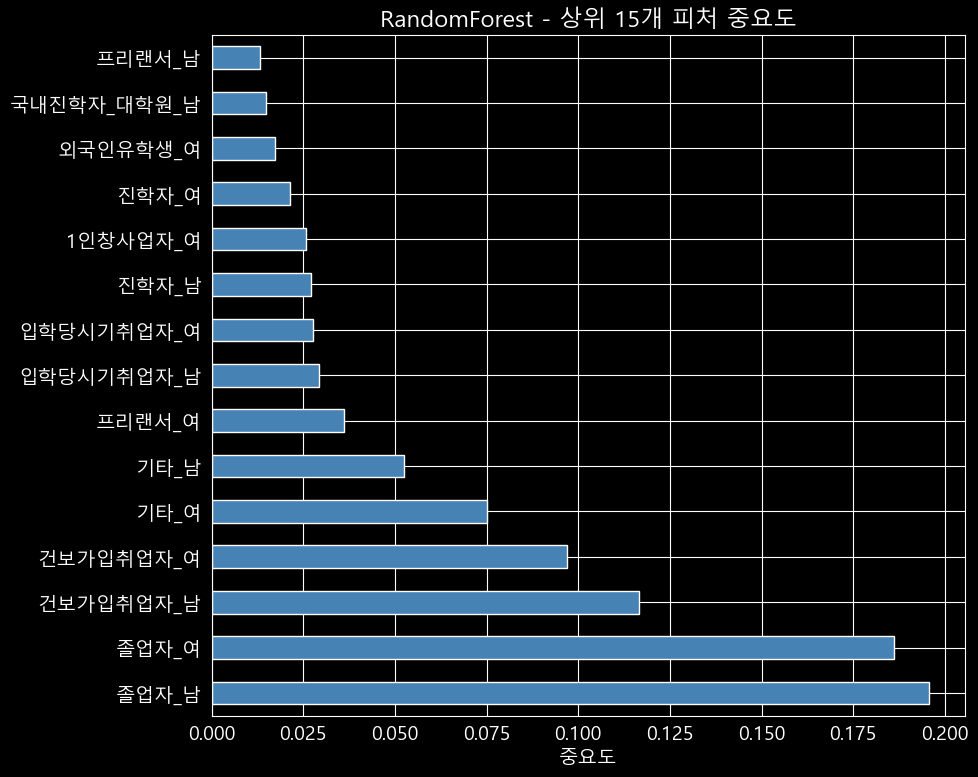

In [18]:
# 피처 중요도
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=numeric_cols
).sort_values(ascending=False)

print('상위 20개 중요한 피처:')
print(feature_importance.head(20))
print()

# 시각화
plt.figure(figsize=(10, 8))
feature_importance.head(15).plot(kind='barh', color='steelblue')
plt.title('RandomForest - 상위 15개 피처 중요도')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

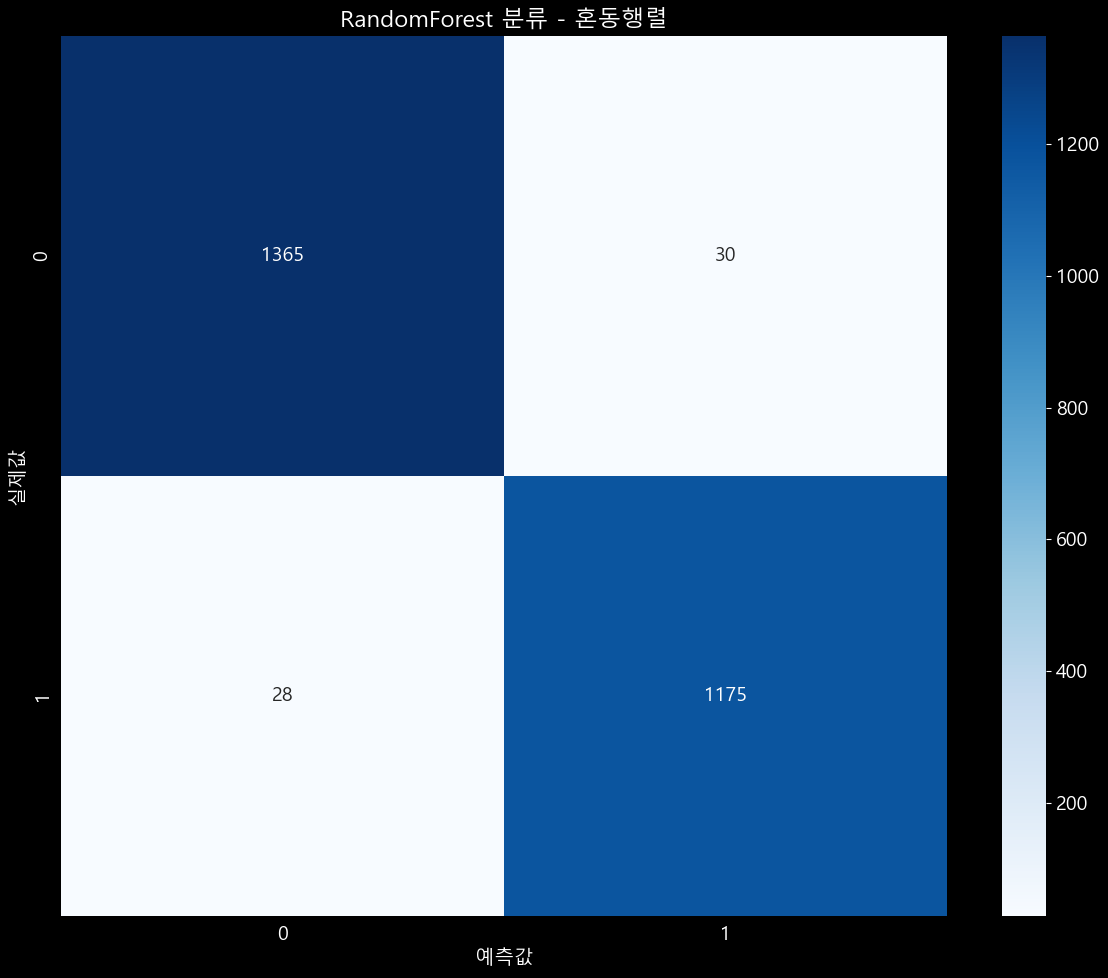

In [19]:
# 혼동행렬 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('RandomForest 분류 - 혼동행렬')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.tight_layout()
plt.show()

In [20]:
# 예측 결과 요약
print('=== 예측 결과 요약 ===')
print()
print(f'테스트 데이터: {len(y_test)}개')
print(f'정확한 예측: {(y_pred_test == y_test).sum()}개')
print(f'틀린 예측: {(y_pred_test != y_test).sum()}개')
print()
print('클래스별 정확도:')
for cls in y_test.unique():
    mask = y_test == cls
    cls_accuracy = accuracy_score(y_test[mask], y_pred_test[mask])
    print(f'  {cls}: {cls_accuracy:.4f} ({cls_accuracy*100:.2f}%)')

=== 예측 결과 요약 ===

테스트 데이터: 2598개
정확한 예측: 2540개
틀린 예측: 58개

클래스별 정확도:
  졸업자_여: 0.9767 (97.67%)
  졸업자_남: 0.9785 (97.85%)


## 8단계: 추가 시각화 (Decision Tree, Learning Curve, ROC-AUC)

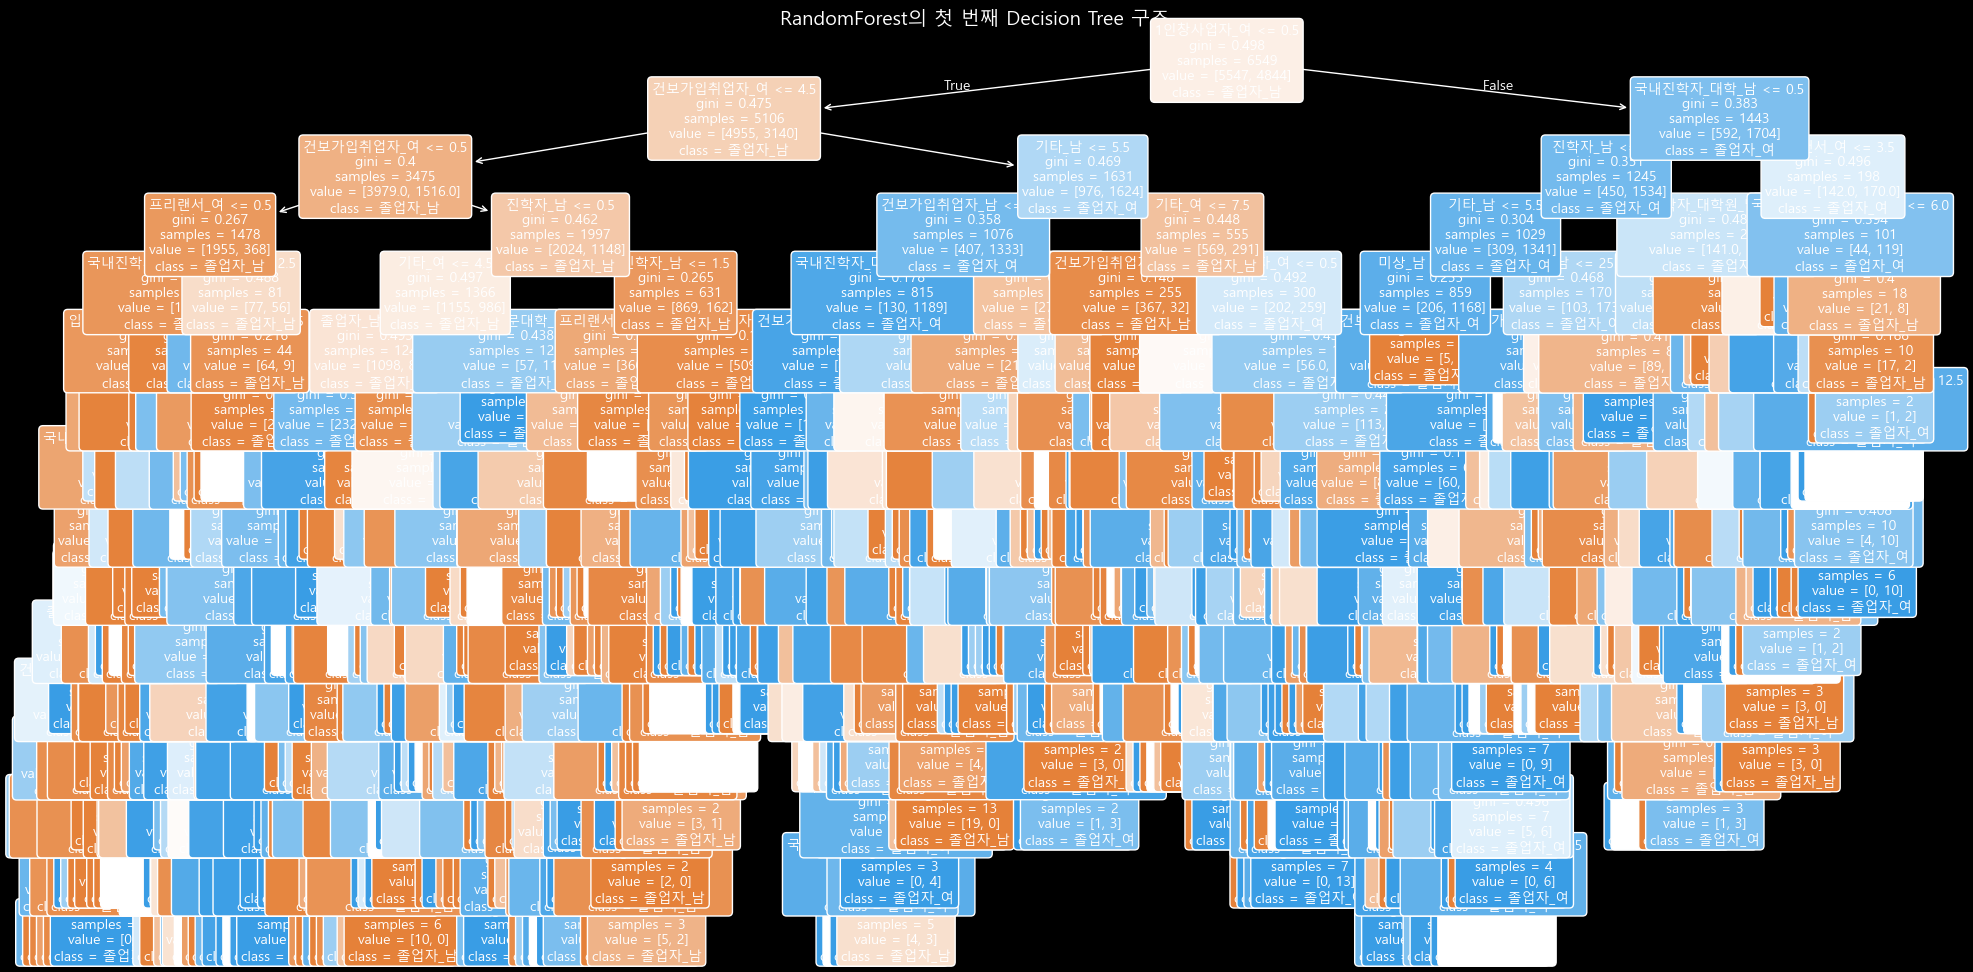

✓ Decision Tree 시각화 완료


In [21]:
# RandomForest에 포함된 첫 번째 Decision Tree 시각화
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(rf_model.estimators_[0],
          feature_names=numeric_cols.tolist(),
          class_names=rf_model.classes_.tolist(),
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('RandomForest의 첫 번째 Decision Tree 구조', fontsize=14)
plt.tight_layout()
plt.show()

print('✓ Decision Tree 시각화 완료')

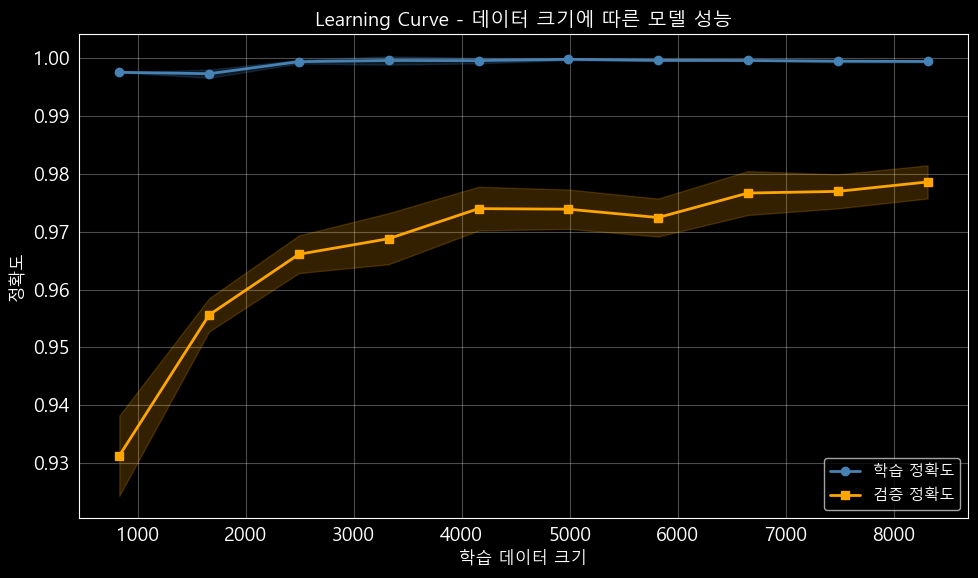

✓ Learning Curve 시각화 완료


In [22]:
# Learning Curve - 학습 데이터 크기에 따른 성능 변화
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X_train, y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

# 평균과 표준편차 계산
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Learning Curve 시각화
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='학습 정확도', linewidth=2, markersize=6)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')

plt.plot(train_sizes, val_mean, 's-', color='orange', label='검증 정확도', linewidth=2, markersize=6)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange')

plt.xlabel('학습 데이터 크기', fontsize=12)
plt.ylabel('정확도', fontsize=12)
plt.title('Learning Curve - 데이터 크기에 따른 모델 성능', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('✓ Learning Curve 시각화 완료')